# Sapien-Simulation Vis

In [1]:
import os
# os.environ["DEBUG"] = "True"

from rlive_common import ActionSpaceType
from rlive_sim import (
    SimulationConfig,
    IntegratedConfig,
    IntegratedBackend,
    SimulationEnv,
)
from rlive_common.utils import get_logger

from vis_config import plot_image_grid, save_images, get_action_list, run_action_list

logger = get_logger(__name__)

[2026-05-16 09:27:30.035] WARNING  - rlive_sim.engine.sapien.world_loading.py:31 - ⚠️ Pinocchio not found. Patching SAPIEN PinocchioModel to prevent Viewer crashes.


C:\Users\kilia\Documents\GitHub\ReLoop_RLive\.venv\Lib\site-packages\sapien\wrapper\pinocchio_model.py:299: UserWarning: pinnochio package is not installed, robotics functionalities will not be available
  warnings.warn(


In [2]:
MAX_STEPS_PER_EPISODE = 800
N_RANDOM = 12

In [3]:
def create_env():
    # Configure integrated backend
    integrated_config = IntegratedConfig(
        backend=IntegratedBackend.SAPIEN,
        width=640//2,
        height=480//2,
    )

    sim_config = SimulationConfig(
        use_integrated=True,
        integrated=integrated_config,
    )

    return SimulationEnv(
        config=sim_config,
        max_episode_steps=MAX_STEPS_PER_EPISODE,
        action_space_type=ActionSpaceType.CARTESIAN,
    )

In [4]:
from rlive_sim import PhysicsState

reset_options = {
    "initial_state": PhysicsState(
        position=[0.0, 0.0, 0.04],
        velocity=[0.0, 0.0, 0.0],
        rotation=[0.0, 0.0, 90.0],
        angular_velocity=[0.0, 0.0, 0.0],
    )
}

env = create_env()
observation_list, action_list, rewards_list = run_action_list(
    env,
    get_action_list(env.action_space, n_random=N_RANDOM),
    reset_options=reset_options,
)
del env

[2026-05-16 09:27:30.970] INFO     - rlive_sim.simulation_env.py:136 - Setting up action space transformer: ActionSpaceType.CARTESIAN
Starting 16 steps...
  [          ]   6%  (1/16 steps)
  [█         ]  18%  (3/16 steps)
  [██        ]  25%  (4/16 steps)
  [███       ]  37%  (6/16 steps)
  [█████     ]  50%  (8/16 steps)
  [█████     ]  56%  (9/16 steps)
  [██████    ]  68%  (11/16 steps)
  [███████   ]  75%  (12/16 steps)
  [████████  ]  87%  (14/16 steps)
  [██████████] 100%  (16/16 steps)
[2026-05-16 09:27:31.860] INFO     - rlive_sim.simulation_env.py:299 - Closing environment.


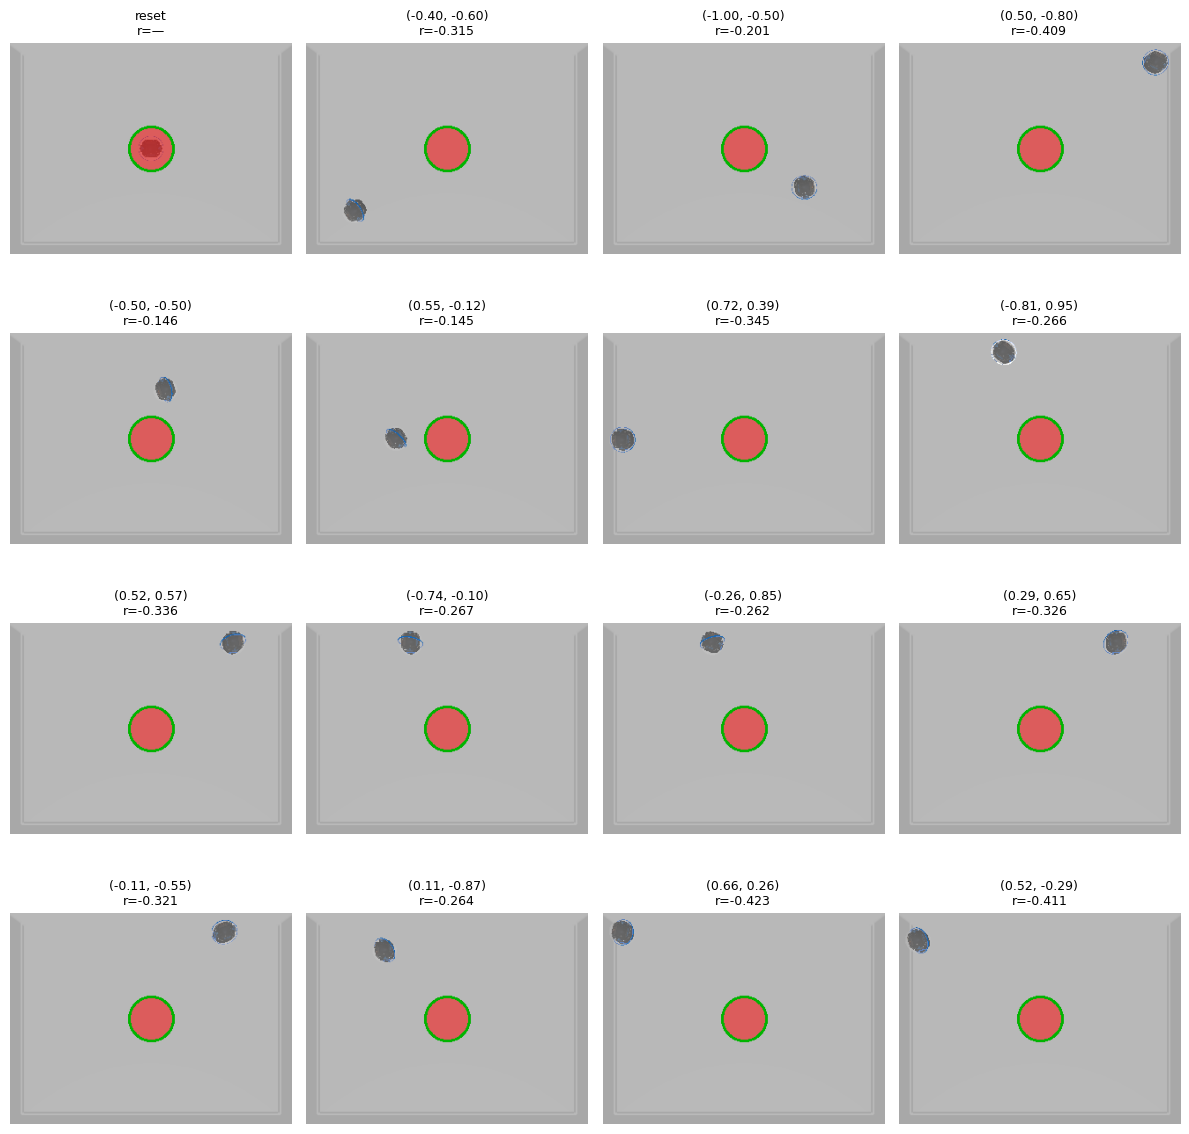

In [5]:
cols = rows = 4
plot_image_grid(
    image_list=observation_list,
    label_list=action_list,
    reward_list=rewards_list,
    rows=rows,
    cols=cols,
)

In [6]:
#save_images(observation_list, action_list, rewards_list, save_dir="image_folder/sapien")
